# PPMI LSTM notebook for multi-step fall prediction

This notebook builds a **sequence model (LSTM)** that uses the patient's visit history to predict whether the **first fall event** happens in the next `HORIZON` visits.

This notebook is designed to match the same data structure and logic as your Cox notebook:

- `BL_CASE` is used as the patient ID
- controls are filtered out if the ID contains `"K"`
- visit dates are read from `V{v}_DateVisit`
- a fall event is defined as the first visit where:
  - `UPO13 >= 1`, or
  - `UPO14 >= 3`
- features are built from visit-level data and **event-defining columns are excluded** to avoid leakage

Along the way, CSV files and figures are saved to make it easier to inspect what is happening.

## 1. Imports and configuration

Adjust in particular:

- `DATA_PATH`
- `VISIT_START` / `VISIT_END`
- `HORIZON`
- `LOOKBACK` (default `3`)
- `MIN_HISTORY_VISITS` (default `3`)
- `BASE_FEATURES`

`LOOKBACK=None` can still be used for full expanding history, but the default is a fixed window for more consistent samples.

In [1]:

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- Feature and run configuration ----
FEATURE_SET = "PPMI_univariate"  # feature set name (used in output path)
N_FEATURES = 15  # kept for run naming compatibility

# ---- Paths ----
DATA_PATH = "../../Data/ppmi_data_merged_wide.csv"

# ---- ID + target + visit ----
ID_COL = "PATNO"
VISIT_COL = "visit_num"
EVENT_COL = "event"

# ---- Sequence task ----
HORIZON = 3                 # predict next HORIZON visits
LOOKBACK = 3                # fixed window (latest LOOKBACK visits)
MIN_HISTORY_VISITS = 3      # require at least this many visits in input
STOP_AFTER_FIRST_EVENT = False

# Curated base features (kept fixed; do not infer all numeric columns).
BASE_FEATURES = [
"NP3RISNG",
"NP3GAIT",
"NP2PTOT",
"MSEADLG",
"NP3PSTBL",
"NP3TOT",
"PIGD",
"NP1RTOT",
"NP1PTOT",
"NHY",
"NP2HYGN",
"NP2DRES",
"NP3LGAGR",
"NP1COG",
"NP2EAT",
]
DELTA_FEATURE_BASES = BASE_FEATURES.copy()

# ---- Training ----
BATCH_SIZE = 16
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.1
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 55
PATIENCE = 5
EVAL_THRESHOLD = 0.5

# ---- Generate unique run name and output directory ----
RUN_NAME = f"top{N_FEATURES}_H{HORIZON}_L{LOOKBACK}_HS{HIDDEN_SIZE}_BS{BATCH_SIZE}_E{EPOCHS}_P{PATIENCE}_N{NUM_LAYERS}_D{int(DROPOUT*100)}"
OUTPUT_DIR = Path(f"../{FEATURE_SET}/results/{RUN_NAME}")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Run name: {RUN_NAME}")
print(f"Output directory: {OUTPUT_DIR}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Run name: top15_H3_L3_HS64_BS16_E55_P5_N1_D10
Output directory: ../PPMI_univariate/results/top15_H3_L3_HS64_BS16_E55_P5_N1_D10
Device: cpu


## 2. Load raw data

This is the same start as in the Cox setup: read the CSV, remove duplicate column names if needed, and verify that the ID column exists.

In [2]:

df = pd.read_csv(DATA_PATH)

# Keep BL and standard V-visits (V01-V21), drop SC and remote style visits.
event_id = df["EVENT_ID"].astype(str).str.strip()
mask_keep = event_id.eq("BL") | event_id.str.match(r"^V\d+$", na=False)
df = df[mask_keep].copy()

# Map visits to numeric order: BL -> 0, V01 -> 1, ...
v_num = pd.to_numeric(event_id.str.extract(r"V(\d+)")[0], errors="coerce")
df[VISIT_COL] = v_num
_df_bl = event_id.eq("BL")
df.loc[_df_bl, VISIT_COL] = 0

df = df[df[VISIT_COL].notna()].copy()
df[VISIT_COL] = df[VISIT_COL].astype(int)

df = df.sort_values([ID_COL, VISIT_COL]).reset_index(drop=True)

# Guardrails for required columns.
required = [ID_COL, "EVENT_ID", VISIT_COL, EVENT_COL]
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Keep configured BASE_FEATURES only (same behavior intent as original ParkVest flow).
missing_base = [c for c in BASE_FEATURES if c not in df.columns]
if missing_base:
    print("Warning: configured BASE_FEATURES missing in data:", missing_base)

non_numeric_base = [
    c for c in BASE_FEATURES
    if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])
]
if non_numeric_base:
    print("Warning: configured BASE_FEATURES are non-numeric and will be skipped:", non_numeric_base)

BASE_FEATURES = [
    c for c in BASE_FEATURES
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]
DELTA_FEATURE_BASES = BASE_FEATURES.copy()

print("Shape:", df.shape)
print("ID column:", ID_COL)
print("Visit column:", VISIT_COL)
print("Target column:", EVENT_COL)
print("# configured numeric BASE_FEATURES used:", len(BASE_FEATURES))
print("BASE_FEATURES used:", BASE_FEATURES)
print("Unique visit IDs kept (sample):", sorted(df["EVENT_ID"].dropna().astype(str).unique())[:12])
print("BL rows kept:", int((df["EVENT_ID"].astype(str).str.strip() == "BL").sum()))
display(df.head(2))

Shape: (8602, 205)
ID column: PATNO
Visit column: visit_num
Target column: event
# configured numeric BASE_FEATURES used: 15
BASE_FEATURES used: ['NP3RISNG', 'NP3GAIT', 'NP2PTOT', 'MSEADLG', 'NP3PSTBL', 'NP3TOT', 'PIGD', 'NP1RTOT', 'NP1PTOT', 'NHY', 'NP2HYGN', 'NP2DRES', 'NP3LGAGR', 'NP1COG', 'NP2EAT']
Unique visit IDs kept (sample): ['BL', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11']
BL rows kept: 1076


/var/folders/95/t78xg19j37g0pzlmfynn1p280000gn/T/ipykernel_55586/3888041188.py:1: DtypeWarning: Columns (48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,PATNO,EVENT_ID,AGE_AT_VISIT,NP1COG,NP1HALL,NP1DPRS,NP1ANXS,NP1APAT,NP1DDS,NP1RTOT,...,FLNFR12M,FLLDRVIS,FLLERVIS,FLLHOSP,SEX,ENROLL_AGE,PIGD,GDS_TOT,event,visit_num
0,3001,BL,65.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1.0,65.1,0.0,1.0,NaN,0
1,3001,V01,65.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1.0,65.1,0.0,NaN,NaN,1


## 3. Remove controls

Same logic as in the Cox notebook: IDs that contain `"K"` are treated as controls and removed.

In [3]:

# PPMI: keep all patients (no ParkVest control filtering).
df0 = df.copy()
df0[ID_COL] = df0[ID_COL].astype(str)

print("After basic cleaning:", df0.shape)
display(df0[[ID_COL, "EVENT_ID", VISIT_COL, EVENT_COL]].head(10))

After basic cleaning: (8602, 205)


,PATNO,EVENT_ID,visit_num,event
0,3001,BL,0,NaN
1,3001,V01,1,NaN
2,3001,V02,2,NaN
3,3001,V03,3,NaN
4,3001,V04,4,NaN
5,3001,V05,5,NaN
6,3001,V06,6,NaN
7,3001,V07,7,NaN
8,3001,V08,8,NaN
9,3001,V09,9,NaN


## 4. Repair and standardize visit dates

We use the same `DateVisit` logic as in the Cox notebook:

- dates are read from `V4_DateVisit` ... `V21_DateVisit`
- unreasonable years or non-increasing dates are marked as bad
- if a date is bad and the previous date exists, it is replaced with `previous + 6 months`

This is useful both for feature engineering and for ensuring the correct chronological order.

In [4]:
# PPMI is already in long format; no ParkVest date repair needed.
# Keep a lightweight compatibility table so downstream diagnostics still work.
repaired = (
    df0[[ID_COL, "EVENT_ID", VISIT_COL]]
    .drop_duplicates()
    .sort_values([ID_COL, VISIT_COL])
    .reset_index(drop=True)
)

# Compatibility variable (used by later diagnostics in this notebook).
pids_with_dropped_visits = set()

repaired.to_csv(OUTPUT_DIR / "visit_index_repaired_like.csv", index=False)

print("PPMI long-format visit index shape:", repaired.shape)
display(repaired.head())

PPMI long-format visit index shape: (8602, 3)


,PATNO,EVENT_ID,visit_num
0,100001,BL,0
1,100001,V02,2
2,100001,V04,4
3,100001,V05,5
4,100001,V06,6


In [5]:
# PPMI diagnostic: patients with last standard visit present (V21 equivalent).
last_visit = 21
has_last_visit = repaired[repaired[VISIT_COL] == last_visit][ID_COL].astype(str).unique().tolist()

print(f"Patients with visit {last_visit}: {len(has_last_visit)}")
print("Example patient IDs:", has_last_visit[:10])

Patients with visit 21: 24
Example patient IDs: ['3001', '3051', '3062', '3067', '3168', '3220', '3269', '3305', '3359', '3366']


## 5. Find the event visit for the first fall

We use the same event definition as in the Cox notebook:

- the first visit where `UPO13 >= 1`
- or the first visit where `UPO14 >= 3`

We automatically select the best available column variant per visit, for example:

- `V{v}_UPO13`
- `V{v}_UPO13_ON`
- `V{v}_UPO13_OFF`
- `V{v}_UPO13_1`

And the same for `UPO14`.

In [6]:

# PPMI event is already provided per visit in EVENT_COL.
# Build patient-level event summary used by split logic.
pat = (
    df0.groupby(ID_COL, as_index=False)
       .agg(
           event=(EVENT_COL, lambda s: int(np.nanmax(pd.to_numeric(s, errors="coerce").fillna(0).values))),
           event_visit=(VISIT_COL, lambda s: np.nan),
       )
)

# First event visit (if any) for diagnostics.
first_evt = (
    df0[pd.to_numeric(df0[EVENT_COL], errors="coerce").fillna(0).astype(int) == 1]
      .groupby(ID_COL)[VISIT_COL]
      .min()
)
pat["event_visit"] = pat[ID_COL].map(first_evt)

pat.to_csv(OUTPUT_DIR / "patient_event_summary.csv", index=False)

print("Event counts:", pat["event"].value_counts(dropna=False).to_dict())
display(pat.head(10))

Event counts: {0: 655, 1: 421}


,PATNO,event,event_visit
0,100001,0,NaN
1,100002,0,NaN
2,100007,1,4.0
3,100012,1,8.0
4,100017,1,8.0
5,100018,1,6.0
6,100268,1,0.0
7,100639,0,NaN
8,100738,0,NaN
9,100842,0,NaN


In [7]:
# PPMI diagnostic export: ID, visit, and event labels used for sequence modeling.
cols_to_save = [ID_COL, "EVENT_ID", VISIT_COL, EVENT_COL]
cols_to_save = [c for c in cols_to_save if c in df0.columns]

df_to_save = df0[cols_to_save].copy()
df_to_save.to_csv(OUTPUT_DIR / "features_and_events.csv", index=False)

print(f"Saved -> {OUTPUT_DIR / 'features_and_events.csv'}")
display(df_to_save.head(10))

Saved -> ../PPMI_univariate/results/top15_H3_L3_HS64_BS16_E55_P5_N1_D10/features_and_events.csv


,PATNO,EVENT_ID,visit_num,event
0,3001,BL,0,NaN
1,3001,V01,1,NaN
2,3001,V02,2,NaN
3,3001,V03,3,NaN
4,3001,V04,4,NaN
5,3001,V05,5,NaN
6,3001,V06,6,NaN
7,3001,V07,7,NaN
8,3001,V08,8,NaN
9,3001,V09,9,NaN


## 6. Build visit-level long format for LSTM

In the Cox notebook you built **intervals** (`start`, `stop`, `event`) between visits.  
For LSTM we instead need **one row per patient per visit**.

So here we do the following:

- use visit `v` as one time point in the sequence
- features are pulled from columns with prefix `V{v}_`
- `visit_date`, `time_since_anchor_years`, `disease_duration_years`, and `age_at_visit` are created explicitly
- `event_here = 1` only at the visit where the first fall occurs
- visits **after** the first event are dropped if `STOP_AFTER_FIRST_EVENT=True`

In [8]:

# PPMI long-format table for LSTM (already one row per patient per visit).
long_df = df0.copy()
long_df[ID_COL] = long_df[ID_COL].astype(str)
long_df[VISIT_COL] = pd.to_numeric(long_df[VISIT_COL], errors="coerce").astype(int)
long_df[EVENT_COL] = pd.to_numeric(long_df[EVENT_COL], errors="coerce").fillna(0).astype(int)

# Keep column names expected by downstream cells.
long_df = long_df.rename(columns={VISIT_COL: "visit", EVENT_COL: "event_here"})

# Add patient-level event summary and first event visit.
first_event_visit = (
    long_df[long_df["event_here"] == 1]
    .groupby(ID_COL)["visit"]
    .min()
)
long_df["event_visit"] = long_df[ID_COL].map(first_event_visit)
long_df["event_any"] = long_df[ID_COL].map(
    long_df.groupby(ID_COL)["event_here"].max()
).fillna(0).astype(int)

# Time proxy for downstream compatibility.
long_df["disease_duration_years"] = (
    long_df["visit"] - long_df.groupby(ID_COL)["visit"].transform("min")
) * 0.5

# Standardize age column naming used elsewhere in notebook.
if "AGE_AT_VISIT" in long_df.columns and "age_at_visit" not in long_df.columns:
    long_df["age_at_visit"] = pd.to_numeric(long_df["AGE_AT_VISIT"], errors="coerce")

long_df = long_df.sort_values([ID_COL, "visit"]).reset_index(drop=True)
long_df.to_csv(OUTPUT_DIR / "visit_level_long_raw.csv", index=False)

print("Long df shape:", long_df.shape)
display(long_df.head())

Long df shape: (8602, 209)


,PATNO,EVENT_ID,AGE_AT_VISIT,NP1COG,NP1HALL,NP1DPRS,NP1ANXS,NP1APAT,NP1DDS,NP1RTOT,...,SEX,ENROLL_AGE,PIGD,GDS_TOT,event_here,visit,event_visit,event_any,disease_duration_years,age_at_visit
0,100001,BL,67.4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,67.4,0.4,0.0,0,0,NaN,0,0.0,67.4
1,100001,V02,67.9,1.0,0.0,0.0,1.0,0.0,0.0,2.0,...,1.0,67.4,0.4,NaN,0,2,NaN,0,1.0,67.9
2,100001,V04,68.5,1.0,0.0,0.0,1.0,0.0,0.0,2.0,...,1.0,67.4,0.4,0.0,0,4,NaN,0,2.0,68.5
3,100001,V05,68.9,1.0,0.0,0.0,1.0,0.0,0.0,2.0,...,1.0,67.4,0.4,NaN,0,5,NaN,0,2.5,68.9
4,100001,V06,69.5,1.0,0.0,0.0,1.0,0.0,0.0,2.0,...,1.0,67.4,0.4,0.0,0,6,NaN,0,3.0,69.5


In [9]:
# PPMI diagnostic: patients with only one valid visit.
visit_counts_tmp = df0.groupby(ID_COL).size().rename("n_visits").reset_index()
one_visit_ids = visit_counts_tmp[visit_counts_tmp["n_visits"] <= 1][ID_COL].astype(str).tolist()

print(f"Patients with <=1 visit ({len(one_visit_ids)}):")
for pid in one_visit_ids[:50]:
    print(f"  {pid}")
if len(one_visit_ids) > 50:
    print("  ...")

Patients with <=1 visit (85):
  100639
  100984
  101035
  101144
  101176
  101243
  101281
  101291
  101317
  101486
  101588
  101753
  101836
  102254
  102307
  102489
  102525
  103924
  104403
  141081
  146547
  152031
  169948
  173487
  238896
  251051
  3007
  3025
  308049
  314625
  3290
  352527
  3536
  385427
  3858
  4006
  411854
  421461
  423325
  423380
  423535
  42451
  428521
  429297
  431210
  431490
  431536
  432416
  435485
  435735
  ...


## 7. Simple check of visit data

This section saves a few summaries of visits per patient and where the first event occurs.

,n_visits
count,1076.000000
mean,7.994424
std,5.472465
min,1.000000
25%,4.000000
50%,6.000000
75%,12.000000
max,23.000000


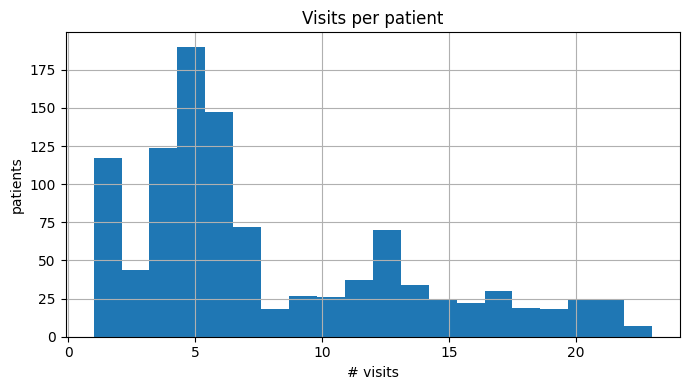

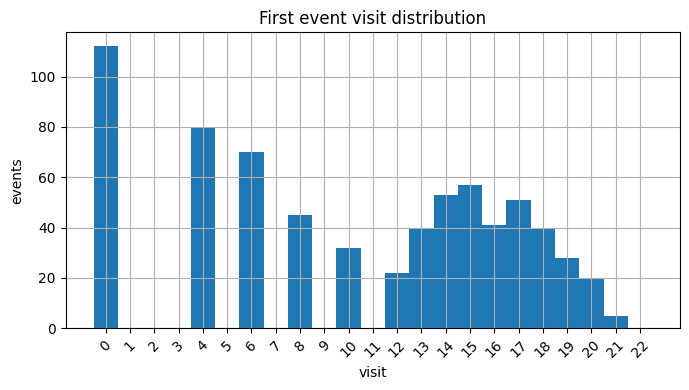

,PATNO,EVENT_ID,AGE_AT_VISIT,NP1COG,NP1HALL,NP1DPRS,NP1ANXS,NP1APAT,NP1DDS,NP1RTOT,...,SEX,ENROLL_AGE,PIGD,GDS_TOT,event_here,visit,event_visit,event_any,disease_duration_years,age_at_visit
17,100007,V04,68.4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,67.2,0.2,1.0,1,4,4.0,1,2.0,68.4
19,100007,V06,69.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,67.2,0.2,1.0,1,6,4.0,1,3.0,69.5
27,100012,V08,69.1,1.0,0.0,3.0,2.0,0.0,1.0,7.0,...,0.0,66.1,0.8,2.0,1,8,8.0,1,4.0,69.1
34,100017,V08,61.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,58.8,0.2,1.0,1,8,8.0,1,4.0,61.8
41,100018,V06,71.9,0.0,1.0,2.0,1.0,0.0,0.0,4.0,...,0.0,69.7,0.4,7.0,1,6,6.0,1,3.0,71.9


In [10]:

visit_counts = long_df.groupby(ID_COL).size().rename("n_visits").reset_index()
visit_counts.to_csv(OUTPUT_DIR / "visit_counts.csv", index=False)

event_rows = long_df[long_df["event_here"] == 1].copy()
event_rows[[ID_COL, "visit", "disease_duration_years"]].to_csv(
    OUTPUT_DIR / "event_visit_rows.csv", index=False
)

display(visit_counts.describe())

plt.figure(figsize=(7, 4))
visit_counts["n_visits"].hist(bins=20)
plt.title("Visits per patient")
plt.xlabel("# visits")
plt.ylabel("patients")
plt.tight_layout()
plt.show()

if len(event_rows) > 0:
    min_v = int(long_df["visit"].min())
    max_v = int(long_df["visit"].max())
    plt.figure(figsize=(7, 4))
    event_rows["visit"].hist(bins=np.arange(min_v, max_v + 2) - 0.5)
    plt.title("First event visit distribution")
    plt.xlabel("visit")
    plt.ylabel("events")
    plt.xticks(range(min_v, max_v + 1), rotation=45)
    plt.tight_layout()
    plt.show()

display(event_rows.head())

## 8. Select features

We intentionally start simple:

- clinically relevant features first
- exclude event-defining columns
- use only numeric features

You can expand `BASE_FEATURES` and `OPTIONAL_FEATURES` later.

In [11]:

candidate_features = BASE_FEATURES 
available_features = [c for c in candidate_features if c in long_df.columns]
missing_features = [c for c in candidate_features if c not in long_df.columns]

print("Available features:", available_features)
print("Missing features:", missing_features)

event_defining_patterns = {"UPO13", "UPO14", "UPO13_ON", "UPO14_ON"}
for feat in available_features:
    assert feat not in event_defining_patterns, f"Feature leakage detected: {feat}"

feature_cols = [c for c in available_features if pd.api.types.is_numeric_dtype(long_df[c])]

if len(feature_cols) == 0:
    raise ValueError("No numeric features selected. Expand BASE_FEATURES / OPTIONAL_FEATURES.")

print("Final numeric feature columns:", feature_cols)
pd.DataFrame({"feature": feature_cols}).to_csv(OUTPUT_DIR / "selected_features.csv", index=False)

Available features: ['NP3RISNG', 'NP3GAIT', 'NP2PTOT', 'MSEADLG', 'NP3PSTBL', 'NP3TOT', 'PIGD', 'NP1RTOT', 'NP1PTOT', 'NHY', 'NP2HYGN', 'NP2DRES', 'NP3LGAGR', 'NP1COG', 'NP2EAT']
Missing features: []
Final numeric feature columns: ['NP3RISNG', 'NP3GAIT', 'NP2PTOT', 'MSEADLG', 'NP3PSTBL', 'NP3TOT', 'PIGD', 'NP1RTOT', 'NP1PTOT', 'NHY', 'NP2HYGN', 'NP2DRES', 'NP3LGAGR', 'NP1COG', 'NP2EAT']


## 9. Split at the patient level

The same patient must never appear in multiple sets.  
Therefore we split by `BL_CASE`, not by visit rows.

We stratify on whether the patient ever had an event or not.

In [12]:

patient_events = pat[[ID_COL, "event"]].drop_duplicates().copy()

ids = patient_events[ID_COL].astype(str).values
y = patient_events["event"].astype(int).values

train_ids, temp_ids, y_train, y_temp = train_test_split(
    ids, y, test_size=0.30, random_state=SEED, stratify=y
)

val_ids, test_ids, y_val, y_test = train_test_split(
    temp_ids, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

pd.DataFrame({ID_COL: train_ids}).to_csv(OUTPUT_DIR / "train_ids.csv", index=False)
pd.DataFrame({ID_COL: val_ids}).to_csv(OUTPUT_DIR / "val_ids.csv", index=False)
pd.DataFrame({ID_COL: test_ids}).to_csv(OUTPUT_DIR / "test_ids.csv", index=False)

def split_summary(name, ids_list):
    sub = patient_events[patient_events[ID_COL].astype(str).isin(ids_list)]
    return pd.Series({
        "n_patients": len(sub),
        "n_events": int(sub["event"].sum()),
        "event_rate": float(sub["event"].mean()) if len(sub) else np.nan,
    }, name=name)

summary = pd.concat([
    split_summary("train", train_ids),
    split_summary("val", val_ids),
    split_summary("test", test_ids),
], axis=1).T

summary.to_csv(OUTPUT_DIR / "split_summary.csv")
display(summary)

,n_patients,n_events,event_rate
train,753.0,295.0,0.391766
val,161.0,63.0,0.391304
test,162.0,63.0,0.388889


## 10. Imputation, delta features, and scaling

Pipeline (leakage-safe):

1. sort by patient and visit
2. forward fill within each patient
3. add delta features (change from the previous visit) within each patient
4. compute training median and training mean/std
5. use **training statistics only** for all splits

This provides both level features and trend features without using future information or information across patients.

In [13]:

train_long = long_df[long_df[ID_COL].isin(train_ids)].copy()
val_long = long_df[long_df[ID_COL].isin(val_ids)].copy()
test_long = long_df[long_df[ID_COL].isin(test_ids)].copy()

# Use inferred base features that actually exist in long_df.
feature_cols = [c for c in BASE_FEATURES if c in long_df.columns and pd.api.types.is_numeric_dtype(long_df[c])]
if len(feature_cols) == 0:
    raise ValueError("No numeric base features found in long_df.")

# ---- Impute NaNs with training means (train-only stats), then StandardScaler fit on train ----
train_means = train_long[feature_cols].mean(skipna=True)
train_means = train_means.fillna(0.0)

for split_df in [train_long, val_long, test_long]:
    split_df[feature_cols] = split_df[feature_cols].apply(pd.to_numeric, errors="coerce")
    split_df[feature_cols] = split_df[feature_cols].fillna(train_means)

scaler = StandardScaler()
scaler.fit(train_long[feature_cols])

for split_df in [train_long, val_long, test_long]:
    split_df[feature_cols] = scaler.transform(split_df[feature_cols])

# ---- Delta features AFTER scaling, ordered by visit ----
def add_delta_features(df_in: pd.DataFrame, id_col: str, base_features):
    out = df_in.sort_values([id_col, "visit"]).copy()
    added = []
    for feat in base_features:
        if feat in out.columns and pd.api.types.is_numeric_dtype(out[feat]):
            dcol = f"delta_{feat}"
            out[dcol] = out.groupby(id_col)[feat].diff()
            added.append(dcol)
    return out, added

train_long, train_delta_cols = add_delta_features(train_long, ID_COL, DELTA_FEATURE_BASES)
val_long, _ = add_delta_features(val_long, ID_COL, DELTA_FEATURE_BASES)
test_long, _ = add_delta_features(test_long, ID_COL, DELTA_FEATURE_BASES)

# Delta NaNs at first visit -> 0.0 to keep dense model input.
for split_df in [train_long, val_long, test_long]:
    for c in train_delta_cols:
        if c in split_df.columns:
            split_df[c] = split_df[c].fillna(0.0)

# Final feature list used by model.
delta_feature_cols = [c for c in train_delta_cols if c in train_long.columns]
feature_cols = feature_cols + [c for c in delta_feature_cols if c not in feature_cols]

train_long.to_csv(OUTPUT_DIR / "train_long_processed.csv", index=False)
val_long.to_csv(OUTPUT_DIR / "val_long_processed.csv", index=False)
test_long.to_csv(OUTPUT_DIR / "test_long_processed.csv", index=False)

stats_df = pd.DataFrame({
    "mean_before_scale": train_means,
    "scaler_mean": pd.Series(scaler.mean_, index=feature_cols[:len(train_means)]),
    "scaler_std": pd.Series(scaler.scale_, index=feature_cols[:len(train_means)]),
})
stats_df.to_csv(OUTPUT_DIR / "feature_stats_train.csv")

print("Base features:", len(BASE_FEATURES))
print("Numeric base features used:", len([c for c in feature_cols if not c.startswith('delta_')]))
print("Delta features added:", len(delta_feature_cols))
print("Total model features:", len(feature_cols))
display(stats_df.head(20))

Base features: 15
Numeric base features used: 15
Delta features added: 15
Total model features: 30


,mean_before_scale,scaler_mean,scaler_std
NP3RISNG,0.415131,0.415131,0.658165
NP3GAIT,0.935686,0.935686,0.686491
NP2PTOT,9.316956,9.316956,6.556249
MSEADLG,87.711579,87.711579,12.085858
NP3PSTBL,0.340950,0.340950,0.725280
NP3TOT,27.705730,27.705730,11.991220
PIGD,0.473082,0.473082,0.473356
NP1RTOT,2.129564,2.129564,2.439529
NP1PTOT,6.283944,6.283944,3.894102
NHY,1.925766,1.925766,0.546951


In [14]:
print("Kolonner i long_df:", long_df.columns.tolist())

Kolonner i long_df: ['PATNO', 'EVENT_ID', 'AGE_AT_VISIT', 'NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1RTOT', 'NP1SLPN', 'NP1SLPD', 'NP1PAIN', 'NP1URIN', 'NP1CNST', 'NP1LTHD', 'NP1FATG', 'NP1PTOT', 'NP2SPCH', 'NP2SALV', 'NP2SWAL', 'NP2EAT', 'NP2DRES', 'NP2HYGN', 'NP2HWRT', 'NP2HOBB', 'NP2TURN', 'NP2TRMR', 'NP2RISE', 'NP2WALK', 'NP2FREZ', 'NP2PTOT', 'PDTRTMNT', 'PDSTATE', 'HRPOSTMED', 'HRDBSON', 'HRDBSOFF', 'PDMEDYN', 'DBSYN', 'ONOFFORDER', 'OFFEXAM', 'OFFNORSN', 'DBSOFFYN', 'DBSOFFTM', 'ONEXAM', 'ONNORSN', 'HIFUYN', 'DBSONYN', 'DBSONTM', 'PDMEDDT', 'PDMEDTM', 'EXAMDT', 'EXAMTM', 'NP3SPCH', 'NP3FACXP', 'NP3RIGN', 'NP3RIGRU', 'NP3RIGLU', 'NP3RIGRL', 'NP3RIGLL', 'NP3FTAPR', 'NP3FTAPL', 'NP3HMOVR', 'NP3HMOVL', 'NP3PRSPR', 'NP3PRSPL', 'NP3TTAPR', 'NP3TTAPL', 'NP3LGAGR', 'NP3LGAGL', 'NP3RISNG', 'NP3GAIT', 'NP3FRZGT', 'NP3PSTBL', 'NP3POSTR', 'NP3BRADY', 'NP3PTRMR', 'NP3PTRML', 'NP3KTRMR', 'NP3KTRML', 'NP3RTARU', 'NP3RTALU', 'NP3RTARL', 'NP3RTALL', 'NP3RTALJ', 'NP3RTCON'

## 11. Build multi-step samples

For each time point `t` we create:

- **input sequence** = history from the same patient up to visit `t`
- **target vector** = whether the first event happens in the next `HORIZON` visits
- **target mask** = which future visits actually exist

New rules for more robust samples:

- fixed lookback window (`LOOKBACK=3` by default)
- minimum history (`MIN_HISTORY_VISITS=3`) before a sample is created

Example with `HORIZON=3` and `LOOKBACK=3`:

- input: the last 3 visits up to and including `t`
- target: visits `t+1`, `t+2`, `t+3`

If an event happens at visit 10, the target is `[0, 1, 0]` for that sample.  
If only visits 9 and 10 exist in the future, the mask is `[1, 1, 0]`.

In [15]:

def build_samples_from_long(df, id_col, visit_col, event_col,
                            features, lookback, horizon):
    samples = []
    for pid, grp in df.groupby(id_col):
        grp = grp.sort_values(visit_col).reset_index(drop=True)
        X = grp[features].values.astype(np.float32)
        y = grp[event_col].values.astype(np.float32)
        n = len(grp)
        for i in range(lookback, n - horizon + 1):
            x_seq = X[i - lookback:i]
            y_seq = y[i:i + horizon]
            mask = (~np.isnan(y_seq)).astype(np.float32)
            y_seq = np.nan_to_num(y_seq, nan=0.0)
            samples.append({
                "patient_id": pid,
                "input_end_visit": int(grp[visit_col].iloc[i - 1]),
                "x": x_seq,
                "y": y_seq,
                "mask": mask,
            })
    return samples


def adapt_samples(raw_samples):
    # Keep compatibility with downstream Dataset/collate/eval code.
    out = []
    for s in raw_samples:
        out.append({
            "patient_id": s["patient_id"],
            "input_end_visit": s["input_end_visit"],
            "seq_len": len(s["x"]),
            "x_seq": s["x"],
            "y": s["y"],
            "y_mask": s["mask"],
            "target_visits": [s["input_end_visit"] + h for h in range(1, HORIZON + 1)],
        })
    return out

train_samples_raw = build_samples_from_long(
    train_long, ID_COL, "visit", "event_here", feature_cols, LOOKBACK, HORIZON
)
val_samples_raw = build_samples_from_long(
    val_long, ID_COL, "visit", "event_here", feature_cols, LOOKBACK, HORIZON
)
test_samples_raw = build_samples_from_long(
    test_long, ID_COL, "visit", "event_here", feature_cols, LOOKBACK, HORIZON
)

train_samples = adapt_samples(train_samples_raw)
val_samples = adapt_samples(val_samples_raw)
test_samples = adapt_samples(test_samples_raw)

print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))
print("Test samples:", len(test_samples))

sample_overview = pd.DataFrame([
    {
        "split": "train",
        "n_samples": len(train_samples),
        "median_seq_len": np.median([s["seq_len"] for s in train_samples]) if train_samples else np.nan,
    },
    {
        "split": "val",
        "n_samples": len(val_samples),
        "median_seq_len": np.median([s["seq_len"] for s in val_samples]) if val_samples else np.nan,
    },
    {
        "split": "test",
        "n_samples": len(test_samples),
        "median_seq_len": np.median([s["seq_len"] for s in test_samples]) if test_samples else np.nan,
    },
])
display(sample_overview)

preview_rows = []
for s in train_samples[:10]:
    row = {
        "patient_id": s["patient_id"],
        "input_end_visit": s["input_end_visit"],
        "seq_len": s["seq_len"],
    }
    for i in range(HORIZON):
        row[f"y_t+{i+1}"] = s["y"][i]
        row[f"mask_t+{i+1}"] = s["y_mask"][i]
    preview_rows.append(row)

sample_preview = pd.DataFrame(preview_rows)
sample_preview.to_csv(OUTPUT_DIR / "sample_preview.csv", index=False)
display(sample_preview.head())

Train samples: 2665
Val samples: 585
Test samples: 620


,split,n_samples,median_seq_len
0,train,2665,3.0
1,val,585,3.0
2,test,620,3.0


,patient_id,input_end_visit,seq_len,y_t+1,mask_t+1,y_t+2,mask_t+2,y_t+3,mask_t+3
0,100001,4,3,0.0,1.0,0.0,1.0,0.0,1.0
1,100001,5,3,0.0,1.0,0.0,1.0,0.0,1.0
2,100001,6,3,0.0,1.0,0.0,1.0,0.0,1.0
3,100012,4,3,0.0,1.0,0.0,1.0,1.0,1.0
4,100012,5,3,0.0,1.0,1.0,1.0,0.0,1.0


In [16]:
def count_contributing_v2(long_split, min_v, lookback, horizon, id_col):
    contributing = 0
    excluded = 0
    
    for pid, g in long_split.groupby(id_col):
        g = g.sort_values("visit").reset_index(drop=True)
        n = len(g)
        event_here = g["event_here"].astype(int).tolist()
        
        has_sample = False
        for t in range(n):
            # Skip event visits
            if event_here[t] == 1:
                continue
            
            # Sequence from max(0, t - lookback + 1) to t+1
            start = max(0, t - lookback + 1)
            seq_len = t - start + 1  # number of visits in the input window
            
            # Must have enough history
            if seq_len < min_v:
                continue
            
            # Must have at least one future target
            has_future = any(t + h < n for h in range(1, horizon + 1))
            if not has_future:
                continue
            
            has_sample = True
            break
        
        if has_sample:
            contributing += 1
        else:
            excluded += 1
    
    return contributing, excluded

# Debug one patient to verify
pid_example = long_df[ID_COL].iloc[0]
g_ex = long_df[long_df[ID_COL] == pid_example].sort_values("visit")
print(f"Eksempel pasient {pid_example}:")
print(f"  Antall visits: {len(g_ex)}")
print(f"  event_here verdier: {g_ex['event_here'].tolist()}")

print(f"\n{'MIN_HIST':<10} {'Split':<10} {'Bidrar':<10} {'Ekskludert':<12}")
print("-" * 44)

for min_v in [3, 4, 5]:
    for split_name, split_ids in [
        ("Train", train_ids),
        ("Val",   val_ids),
        ("Test",  test_ids),
    ]:
        split_df = long_df[long_df[ID_COL].isin(split_ids)]
        contrib, excl = count_contributing_v2(
            split_df, min_v, LOOKBACK, HORIZON, ID_COL
        )
        print(f"{min_v:<10} {split_name:<10} {contrib:<10} {excl:<12}")
    print()

Eksempel pasient 100001:
  Antall visits: 8
  event_here verdier: [0, 0, 0, 0, 0, 0, 0, 0]

MIN_HIST   Split      Bidrar     Ekskludert  
--------------------------------------------
3          Train      638        115         
3          Val        136        25          
3          Test       129        33          

4          Train      0          753         
4          Val        0          161         
4          Test       0          162         

5          Train      0          753         
5          Val        0          161         
5          Test       0          162         



In [17]:
# ── Dataset split summary table ───────────────────────────────────────────────
def split_summary(samples, name):
    n_patients = len(set(s["patient_id"] for s in samples))
    n_samples  = len(samples)

    fall_samples = sum(
        1 for s in samples 
        if any(s["y"][h] == 1 and s["y_mask"][h] == 1 
               for h in range(HORIZON))
    )
    non_fall_samples = n_samples - fall_samples
    pos_rate = fall_samples / n_samples * 100 if n_samples > 0 else 0

    return {
        "Split":            name,
        "Patients":         n_patients,
        "Samples":          n_samples,
        "Fall samples":     fall_samples,
        "Non-fall samples": non_fall_samples,
        "Positive rate":    f"{pos_rate:.1f}%",
    }

rows = [
    split_summary(train_samples, "Train"),
    split_summary(val_samples,   "Validation"),
    split_summary(test_samples,  "Test"),
]

# Total row
total_patients = (
    len(set(s["patient_id"] for s in train_samples)) +
    len(set(s["patient_id"] for s in val_samples)) +
    len(set(s["patient_id"] for s in test_samples))
)
total_samples      = sum(r["Samples"]          for r in rows)
total_fall         = sum(r["Fall samples"]     for r in rows)
total_nonfall      = sum(r["Non-fall samples"] for r in rows)
total_pos_rate     = total_fall / total_samples * 100 if total_samples > 0 else 0

rows.append({
    "Split":            "Total",
    "Patients":         total_patients,
    "Samples":          total_samples,
    "Fall samples":     total_fall,
    "Non-fall samples": total_nonfall,
    "Positive rate":    f"{total_pos_rate:.1f}%",
})

df_summary = pd.DataFrame(rows)
display(df_summary)

# Save to CSV
df_summary.to_csv(OUTPUT_DIR / f"split_summary_{RUN_NAME}.csv", index=False)
print(f"Saved split summary → {OUTPUT_DIR / f'split_summary_{RUN_NAME}.csv'}")

,Split,Patients,Samples,Fall samples,Non-fall samples,Positive rate
0,Train,417,2665,542,2123,20.3%
1,Validation,94,585,119,466,20.3%
2,Test,90,620,116,504,18.7%
3,Total,601,3870,777,3093,20.1%


Saved split summary → ../PPMI_univariate/results/top15_H3_L3_HS64_BS16_E55_P5_N1_D10/split_summary_top15_H3_L3_HS64_BS16_E55_P5_N1_D10.csv


## 12. Dataset, collate function, and padding

The LSTM needs batches with equal length. Therefore:

- sequences are padded to the max length in the batch
- we store the true sequence lengths
- the target mask indicates which future labels are valid

In [18]:

class SequenceDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "patient_id": s["patient_id"],
            "input_end_visit": s["input_end_visit"],
            "x_seq": torch.tensor(s["x_seq"], dtype=torch.float32),
            "y": torch.tensor(s["y"], dtype=torch.float32),
            "y_mask": torch.tensor(s["y_mask"], dtype=torch.float32),
        }

def collate_fn(batch):
    x_list = [b["x_seq"] for b in batch]
    lengths = torch.tensor([len(x) for x in x_list], dtype=torch.long)
    x_padded = pad_sequence(x_list, batch_first=True)

    y = torch.stack([b["y"] for b in batch], dim=0)
    y_mask = torch.stack([b["y_mask"] for b in batch], dim=0)

    patient_ids = [b["patient_id"] for b in batch]
    input_end_visit = torch.tensor([b["input_end_visit"] for b in batch], dtype=torch.long)

    return {
        "patient_id": patient_ids,
        "input_end_visit": input_end_visit,
        "x": x_padded,
        "lengths": lengths,
        "y": y,
        "y_mask": y_mask,
    }

train_ds = SequenceDataset(train_samples)
val_ds = SequenceDataset(val_samples)
test_ds = SequenceDataset(test_samples)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

first_batch = next(iter(train_loader))
print("x batch:", first_batch["x"].shape)
print("lengths:", first_batch["lengths"][:10])
print("y batch:", first_batch["y"].shape)
print("y_mask batch:", first_batch["y_mask"].shape)

x batch: torch.Size([16, 3, 30])
lengths: tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3])
y batch: torch.Size([16, 3])
y_mask batch: torch.Size([16, 3])


## 13. LSTM model

A simple baseline with easily adjustable regularization:

- standard: one LSTM layer and `dropout=0.0`
- alternative: two layers + moderate dropout (for example `NUM_LAYERS=2`, `DROPOUT=0.2`)
- uses the last hidden state
- a linear output layer gives `HORIZON` logits
- sigmoid is applied implicitly in the loss/evaluation

In [19]:

class MultiStepLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0, horizon=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        last_hidden = h_n[-1]
        logits = self.head(last_hidden)
        return logits

model = MultiStepLSTM(
    input_size=len(feature_cols),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    horizon=HORIZON,
).to(DEVICE)

print(model)

MultiStepLSTM(
  (lstm): LSTM(30, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=3, bias=True)
)


## 14. Masked loss, class imbalance, and evaluation functions

We only compute loss on target positions that actually exist.  
That means future padding does **not** affect training.

In addition, we use `pos_weight` (computed only from train targets) to handle rare positive events.  
The evaluation includes both discrimination (AUC/AP) and threshold-based clinical metrics (sensitivity, specificity, precision, recall).

In [20]:

def compute_target_distribution(samples, split_name, horizon):
    rows = []
    if len(samples) == 0:
        for h in range(1, horizon + 1):
            rows.append({
                "split": split_name,
                "horizon": f"t+{h}",
                "n_valid": 0,
                "n_positive": 0,
                "positive_rate": np.nan,
            })
        return pd.DataFrame(rows)

    y = np.stack([s["y"] for s in samples], axis=0)
    mask = np.stack([s["y_mask"] for s in samples], axis=0)

    for h in range(horizon):
        valid = mask[:, h] == 1
        n_valid = int(valid.sum())
        n_pos = int(y[valid, h].sum()) if n_valid > 0 else 0
        pos_rate = float(n_pos / n_valid) if n_valid > 0 else np.nan
        rows.append({
            "split": split_name,
            "horizon": f"t+{h+1}",
            "n_valid": n_valid,
            "n_positive": n_pos,
            "positive_rate": pos_rate,
        })
    return pd.DataFrame(rows)

def compute_pos_weight_from_samples(samples, horizon):
    if len(samples) == 0:
        return np.ones(horizon, dtype=np.float32)

    y = np.stack([s["y"] for s in samples], axis=0)
    mask = np.stack([s["y_mask"] for s in samples], axis=0)

    pos_weights = []
    for h in range(horizon):
        valid = mask[:, h] == 1
        n_valid = int(valid.sum())
        if n_valid == 0:
            pos_weights.append(1.0)
            continue

        n_pos = float(y[valid, h].sum())
        n_neg = float(n_valid - n_pos)

        if n_pos <= 0:
            pos_weights.append(1.0)
        else:
            pos_weights.append(max(n_neg / n_pos, 1.0))

    return np.array(pos_weights, dtype=np.float32)

target_dist_df = pd.concat([
    compute_target_distribution(train_samples, "train", HORIZON),
    compute_target_distribution(val_samples, "val", HORIZON),
    compute_target_distribution(test_samples, "test", HORIZON),
]).reset_index(drop=True)
target_dist_df.to_csv(OUTPUT_DIR / "target_distribution_by_horizon.csv", index=False)
display(target_dist_df)

POS_WEIGHT = compute_pos_weight_from_samples(train_samples, HORIZON)
POS_WEIGHT_TENSOR = torch.tensor(POS_WEIGHT, dtype=torch.float32, device=DEVICE)
print("Train pos_weight per horizon:", POS_WEIGHT.tolist())

def masked_bce_with_logits_loss(logits, targets, mask, pos_weight=None):
    per_elem = nn.functional.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    masked = per_elem * mask
    denom = mask.sum().clamp(min=1.0)
    return masked.sum() / denom

def confusion_metrics(y_true, y_pred_class):
    y_true = y_true.astype(int)
    y_pred_class = y_pred_class.astype(int)

    tp = int(((y_true == 1) & (y_pred_class == 1)).sum())
    tn = int(((y_true == 0) & (y_pred_class == 0)).sum())
    fp = int(((y_true == 0) & (y_pred_class == 1)).sum())
    fn = int(((y_true == 1) & (y_pred_class == 0)).sum())

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = sensitivity

    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "recall": recall,
    }

def resolve_threshold_map(threshold, horizon):
    if isinstance(threshold, dict):
        return {h: float(threshold.get(h, 0.5)) for h in range(1, horizon + 1)}
    if isinstance(threshold, (list, tuple, np.ndarray)):
        if len(threshold) != horizon:
            raise ValueError(f"Threshold list length must equal HORIZON={horizon}.")
        return {h: float(threshold[h - 1]) for h in range(1, horizon + 1)}
    return {h: float(threshold) for h in range(1, horizon + 1)}

@torch.no_grad()
def evaluate_model(model, loader, device, threshold=0.5, pos_weight=None):
    model.eval()

    total_loss = 0.0
    total_weight = 0.0

    all_rows = []
    threshold_map = resolve_threshold_map(threshold, HORIZON)

    for batch in loader:
        x = batch["x"].to(device)
        lengths = batch["lengths"].to(device)
        y = batch["y"].to(device)
        y_mask = batch["y_mask"].to(device)

        logits = model(x, lengths)
        loss = masked_bce_with_logits_loss(logits, y, y_mask, pos_weight=pos_weight)

        weight = float(y_mask.sum().item())
        total_loss += float(loss.item()) * weight
        total_weight += weight

        probs = torch.sigmoid(logits).cpu().numpy()
        y_np = y.cpu().numpy()
        mask_np = y_mask.cpu().numpy()

        for i in range(len(batch["patient_id"])):
            row = {
                "patient_id": batch["patient_id"][i],
                "input_end_visit": int(batch["input_end_visit"][i].item()),
            }
            for h in range(HORIZON):
                row[f"target_t+{h+1}"] = float(y_np[i, h])
                row[f"mask_t+{h+1}"] = float(mask_np[i, h])
                row[f"prob_t+{h+1}"] = float(probs[i, h])
            all_rows.append(row)

    avg_loss = total_loss / max(total_weight, 1.0)
    pred_df = pd.DataFrame(all_rows)

    metrics = {"loss": avg_loss}

    # per-horizon AUC / AP / F1 + confusion-based metrics
    for h in range(1, HORIZON + 1):
        sub = pred_df[pred_df[f"mask_t+{h}"] == 1].copy()
        y_true = sub[f"target_t+{h}"].values
        y_prob = sub[f"prob_t+{h}"].values

        if len(np.unique(y_true)) >= 2:
            metrics[f"auc_t+{h}"] = roc_auc_score(y_true, y_prob)
            metrics[f"ap_t+{h}"] = average_precision_score(y_true, y_prob)
        else:
            metrics[f"auc_t+{h}"] = np.nan
            metrics[f"ap_t+{h}"] = np.nan

        threshold_h = threshold_map[h]
        metrics[f"threshold_t+{h}"] = threshold_h

        y_pred = (y_prob >= threshold_h).astype(int) if len(y_prob) > 0 else np.array([], dtype=int)
        
        # Compute F1-score
        if len(y_prob) > 0:
            metrics[f"f1_t+{h}"] = f1_score(y_true, y_pred, zero_division=0)
        else:
            metrics[f"f1_t+{h}"] = np.nan
        
        cm = confusion_metrics(y_true, y_pred) if len(y_prob) > 0 else {
            "tp": 0, "tn": 0, "fp": 0, "fn": 0,
            "sensitivity": np.nan, "specificity": np.nan,
            "precision": np.nan, "recall": np.nan
        }

        metrics[f"tp_t+{h}"] = cm["tp"]
        metrics[f"tn_t+{h}"] = cm["tn"]
        metrics[f"fp_t+{h}"] = cm["fp"]
        metrics[f"fn_t+{h}"] = cm["fn"]
        metrics[f"sensitivity_t+{h}"] = cm["sensitivity"]
        metrics[f"specificity_t+{h}"] = cm["specificity"]
        metrics[f"precision_t+{h}"] = cm["precision"]
        metrics[f"recall_t+{h}"] = cm["recall"]

    return metrics, pred_df


,split,horizon,n_valid,n_positive,positive_rate
0,train,t+1,2665,173,0.064916
1,train,t+2,2665,262,0.098311
2,train,t+3,2665,302,0.113321
3,val,t+1,585,41,0.070085
4,val,t+2,585,59,0.100855
5,val,t+3,585,64,0.109402
6,test,t+1,620,35,0.056452
7,test,t+2,620,49,0.079032
8,test,t+3,620,62,0.100000


Train pos_weight per horizon: [14.404623985290527, 9.17175579071045, 7.824503421783447]


## 15. Train the model

Early stopping is driven by validation loss.  
A training history CSV is also saved.

In [21]:

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_loss = np.inf
best_state = None
bad_epochs = 0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_weight_sum = 0.0

    for batch in train_loader:
        x = batch["x"].to(DEVICE)
        lengths = batch["lengths"].to(DEVICE)
        y = batch["y"].to(DEVICE)
        y_mask = batch["y_mask"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = masked_bce_with_logits_loss(logits, y, y_mask, pos_weight=POS_WEIGHT_TENSOR)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        weight = float(y_mask.sum().item())
        train_loss_sum += float(loss.item()) * weight
        train_weight_sum += weight

    train_loss = train_loss_sum / max(train_weight_sum, 1.0)

    val_metrics, _ = evaluate_model(
        model,
        val_loader,
        DEVICE,
        threshold=EVAL_THRESHOLD,
        pos_weight=POS_WEIGHT_TENSOR,
    )
    val_loss = val_metrics["loss"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    }
    for h in range(1, HORIZON + 1):
        row[f"val_auc_t+{h}"] = val_metrics.get(f"auc_t+{h}", np.nan)
        row[f"val_ap_t+{h}"] = val_metrics.get(f"ap_t+{h}", np.nan)
        row[f"val_sensitivity_t+{h}"] = val_metrics.get(f"sensitivity_t+{h}", np.nan)
        row[f"val_specificity_t+{h}"] = val_metrics.get(f"specificity_t+{h}", np.nan)

    history.append(row)

    auc_msg = " | ".join([
        f"val_auc_t+{h}={row[f'val_auc_t+{h}']:.3f}" if pd.notna(row[f'val_auc_t+{h}']) else f"val_auc_t+{h}=nan"
        for h in range(1, HORIZON + 1)
    ])

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | {auc_msg}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
display(history_df.tail())

if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(best_state, OUTPUT_DIR / "best_lstm_model.pt")
    print("Saved best model to", OUTPUT_DIR / "best_lstm_model.pt")

Epoch 01 | train_loss=1.2202 | val_loss=1.1913 | val_auc_t+1=0.717 | val_auc_t+2=0.666 | val_auc_t+3=0.643
Epoch 02 | train_loss=1.1624 | val_loss=1.1773 | val_auc_t+1=0.706 | val_auc_t+2=0.652 | val_auc_t+3=0.646
Epoch 03 | train_loss=1.1324 | val_loss=1.1795 | val_auc_t+1=0.711 | val_auc_t+2=0.661 | val_auc_t+3=0.648
Epoch 04 | train_loss=1.1091 | val_loss=1.1833 | val_auc_t+1=0.716 | val_auc_t+2=0.659 | val_auc_t+3=0.653
Epoch 05 | train_loss=1.0775 | val_loss=1.2275 | val_auc_t+1=0.717 | val_auc_t+2=0.657 | val_auc_t+3=0.652
Epoch 06 | train_loss=1.0437 | val_loss=1.1925 | val_auc_t+1=0.725 | val_auc_t+2=0.642 | val_auc_t+3=0.650
Epoch 07 | train_loss=0.9933 | val_loss=1.2649 | val_auc_t+1=0.725 | val_auc_t+2=0.652 | val_auc_t+3=0.655
Early stopping at epoch 7


,epoch,train_loss,val_loss,val_auc_t+1,val_ap_t+1,val_sensitivity_t+1,val_specificity_t+1,val_auc_t+2,val_ap_t+2,val_sensitivity_t+2,val_specificity_t+2,val_auc_t+3,val_ap_t+3,val_sensitivity_t+3,val_specificity_t+3
2,3,1.132433,1.179465,0.710500,0.129594,0.658537,0.654412,0.660953,0.176413,0.694915,0.615970,0.648093,0.150540,0.625000,0.598848
3,4,1.109141,1.183268,0.716194,0.129898,0.707317,0.663603,0.659051,0.179068,0.644068,0.595057,0.652951,0.161197,0.656250,0.585413
4,5,1.077525,1.227535,0.717270,0.129123,0.634146,0.693015,0.657472,0.177270,0.593220,0.640684,0.652051,0.175981,0.625000,0.608445
5,6,1.043711,1.192544,0.724758,0.133796,0.707317,0.658088,0.642263,0.176541,0.644068,0.549430,0.649862,0.171083,0.671875,0.508637
6,7,0.993340,1.264869,0.725386,0.142749,0.536585,0.753676,0.652188,0.196870,0.508475,0.667300,0.654661,0.173843,0.609375,0.648752


Saved best model to ../PPMI_univariate/results/top15_H3_L3_HS64_BS16_E55_P5_N1_D10/best_lstm_model.pt


## 16. Training curves

This gives a quick visual check of whether the model is learning or starting to overfit.

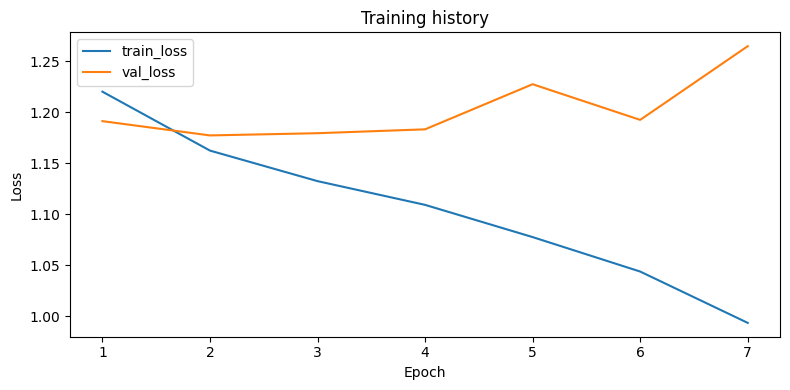

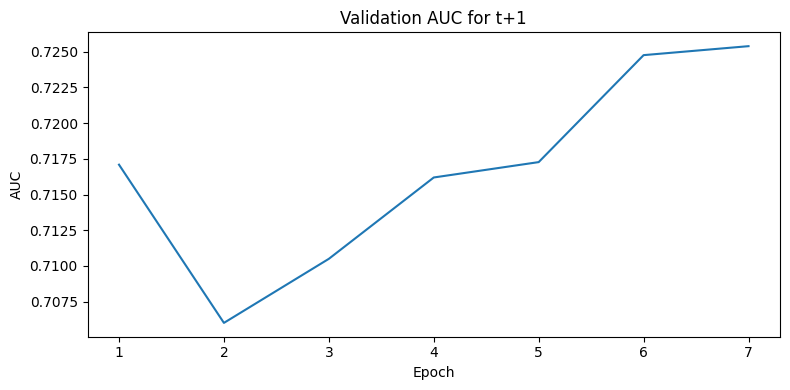

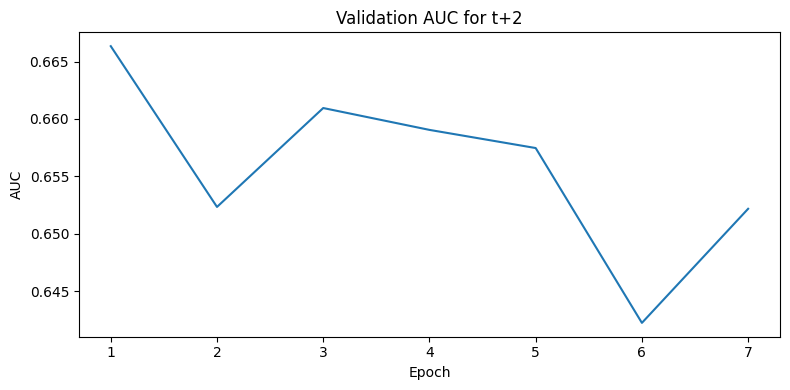

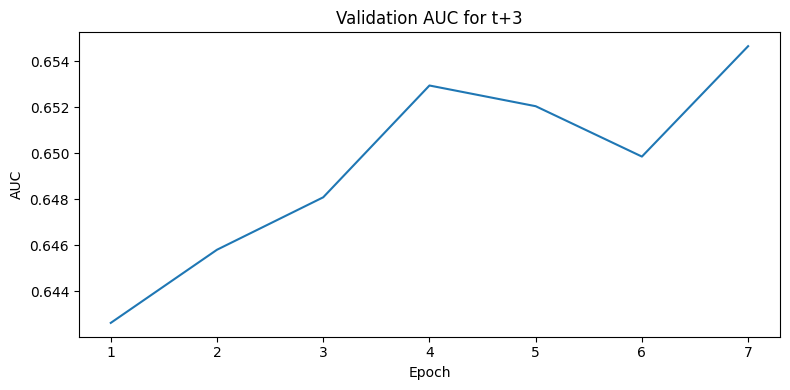

In [22]:

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_history_loss.png", dpi=300, bbox_inches="tight")
plt.show()

for h in range(1, HORIZON + 1):
    col = f"val_auc_t+{h}"
    if col in history_df.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(history_df["epoch"], history_df[col])
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.title(f"Validation AUC for t+{h}")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"val_auc_tplus{h}.png", dpi=300, bbox_inches="tight")
        plt.show()

## 17. Evaluation on train / val / test

We score all samples and save the predictions.  
You get both:

- loss (same masked/weighted definition as in training)
- AUC per horizon
- average precision per horizon
- threshold-based metrics per horizon: sensitivity, specificity, precision, and recall
- a CSV with targets, masks, and probabilities

In [23]:

train_metrics, train_pred = evaluate_model(
    model, train_loader, DEVICE, threshold=EVAL_THRESHOLD, pos_weight=POS_WEIGHT_TENSOR
)
val_metrics, val_pred = evaluate_model(
    model, val_loader, DEVICE, threshold=EVAL_THRESHOLD, pos_weight=POS_WEIGHT_TENSOR
)
test_metrics, test_pred = evaluate_model(
    model, test_loader, DEVICE, threshold=EVAL_THRESHOLD, pos_weight=POS_WEIGHT_TENSOR
)

train_pred.to_csv(OUTPUT_DIR / "train_predictions.csv", index=False)
val_pred.to_csv(OUTPUT_DIR / "val_predictions.csv", index=False)
test_pred.to_csv(OUTPUT_DIR / "test_predictions_default_threshold.csv", index=False)

run_config = {
    "BATCH_SIZE": BATCH_SIZE,
    "HIDDEN_SIZE": HIDDEN_SIZE,
    "NUM_LAYERS": NUM_LAYERS,
    "DROPOUT": DROPOUT,
    "LR": LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
    "EVAL_THRESHOLD": EVAL_THRESHOLD,
    "HORIZON": HORIZON,
    "LOOKBACK": LOOKBACK,
    "MIN_HISTORY_VISITS": MIN_HISTORY_VISITS,
}

metrics_rows = []
for split_name, metrics in [("train", train_metrics), ("val", val_metrics), ("test", test_metrics)]:
    row = {
        "split": split_name,
        "threshold_source": "default_eval_threshold",
        **run_config,
        **metrics,
    }
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUTPUT_DIR / f"metrics_summary_default_{RUN_NAME}.csv", index=False)
display(metrics_df)


,split,threshold_source,BATCH_SIZE,HIDDEN_SIZE,NUM_LAYERS,DROPOUT,LR,WEIGHT_DECAY,EPOCHS,PATIENCE,...,threshold_t+3,f1_t+3,tp_t+3,tn_t+3,fp_t+3,fn_t+3,sensitivity_t+3,specificity_t+3,precision_t+3,recall_t+3
0,train,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.5,0.263071,239,1087,1276,63,0.791391,0.460008,0.157756,0.791391
1,val,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.5,0.272981,49,275,246,15,0.765625,0.527831,0.166102,0.765625
2,test,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.5,0.228288,46,263,295,16,0.741935,0.471326,0.134897,0.741935


In [24]:

# 17a. Bootstrap confidence intervals for test AUC
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

SEED = 42
N_BOOTSTRAP_SAMPLES = 1000

bootstrap_rows = []
rng = np.random.RandomState(SEED)

for h in range(1, HORIZON + 1):
    target_col = f"target_t+{h}"
    mask_col = f"mask_t+{h}"
    prob_col = f"prob_t+{h}"

    sub = test_pred[test_pred[mask_col] == 1].copy()
    y_true = sub[target_col].astype(int).to_numpy()
    y_prob = sub[prob_col].astype(float).to_numpy()

    if len(np.unique(y_true)) < 2:
        auc = np.nan
        ci_lo = np.nan
        ci_hi = np.nan
    else:
        auc = roc_auc_score(y_true, y_prob)

        boot_aucs = []
        for _ in range(N_BOOTSTRAP_SAMPLES):
            bs = resample(
                np.arange(len(y_true)),
                replace=True,
                n_samples=len(y_true),
                random_state=int(rng.randint(0, 2**31 - 1)),
            )
            y_bs = y_true[bs]
            p_bs = y_prob[bs]

            if len(np.unique(y_bs)) < 2:
                continue

            boot_aucs.append(roc_auc_score(y_bs, p_bs))

        if len(boot_aucs) == 0:
            ci_lo = np.nan
            ci_hi = np.nan
        else:
            ci_lo = float(np.percentile(boot_aucs, 2.5))
            ci_hi = float(np.percentile(boot_aucs, 97.5))

    print(f"t+{h}: AUC={auc:.3f}  95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]")

    bootstrap_rows.append({
        "horizon": f"t+{h}",
        "auc": auc,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
    })

bootstrap_ci_df = pd.DataFrame(bootstrap_rows)
bootstrap_ci_df.to_csv(OUTPUT_DIR / f"bootstrap_ci_{RUN_NAME}.csv", index=False)
print("Saved:", OUTPUT_DIR / f"bootstrap_ci_{RUN_NAME}.csv")

# Merge bootstrap CI results into test row of metrics summary
test_metrics_with_ci = test_metrics.copy()
for h in range(1, HORIZON + 1):
    bs_row = bootstrap_ci_df[bootstrap_ci_df["horizon"] == f"t+{h}"].iloc[0]
    test_metrics_with_ci[f"ci_lo_t+{h}"] = bs_row["ci_lo"]
    test_metrics_with_ci[f"ci_hi_t+{h}"] = bs_row["ci_hi"]

print("Bootstrap CI columns merged into test_metrics_with_ci")


t+1: AUC=0.682  95% CI=[0.602, 0.751]
t+2: AUC=0.657  95% CI=[0.576, 0.730]
t+3: AUC=0.617  95% CI=[0.541, 0.686]
Saved: ../PPMI_univariate/results/top15_H3_L3_HS64_BS16_E55_P5_N1_D10/bootstrap_ci_top15_H3_L3_HS64_BS16_E55_P5_N1_D10.csv
Bootstrap CI columns merged into test_metrics_with_ci


In [25]:

## 17b. Find optimal threshold per horizon on the validation set

def find_best_threshold(pred_df, horizon):
    best_thresh = 0.5
    best_j = -1

    sub = pred_df[pred_df[f"mask_t+{horizon}"] == 1].copy()
    y_true = sub[f"target_t+{horizon}"].values
    y_prob = sub[f"prob_t+{horizon}"].values

    for thresh in np.arange(0.1, 0.9, 0.02):
        preds = (y_prob >= thresh).astype(int)
        tp = ((preds == 1) & (y_true == 1)).sum()
        tn = ((preds == 0) & (y_true == 0)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        fn = ((preds == 0) & (y_true == 1)).sum()

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        j = sens + spec - 1

        if j > best_j:
            best_j = j
            best_thresh = thresh

    return best_thresh, best_j

# Evaluate on the validation set and get pred_df
_, val_pred_df = evaluate_model(model, val_loader, DEVICE,
                                threshold=0.5, pos_weight=POS_WEIGHT_TENSOR)

BEST_THRESHOLDS = {}
for h in range(1, HORIZON + 1):
    thresh, j = find_best_threshold(val_pred_df, h)
    BEST_THRESHOLDS[h] = thresh
    print(f"t+{h}: best threshold = {thresh:.2f},  Youden J = {j:.3f}")

# Re-evaluate test set using per-horizon optimal thresholds and save as primary summary output
test_metrics_opt, test_pred_opt = evaluate_model(
    model,
    test_loader,
    DEVICE,
    threshold=BEST_THRESHOLDS,
    pos_weight=POS_WEIGHT_TENSOR,
 )
test_pred_opt.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

run_config = {
    "BATCH_SIZE": BATCH_SIZE,
    "HIDDEN_SIZE": HIDDEN_SIZE,
    "NUM_LAYERS": NUM_LAYERS,
    "DROPOUT": DROPOUT,
    "LR": LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
    "EVAL_THRESHOLD": EVAL_THRESHOLD,
    "HORIZON": HORIZON,
    "LOOKBACK": LOOKBACK,
    "MIN_HISTORY_VISITS": MIN_HISTORY_VISITS,
}

metrics_rows = [
    {"split": "train", "threshold_source": "default_eval_threshold", **run_config, **train_metrics},
    {"split": "val", "threshold_source": "default_eval_threshold", **run_config, **val_metrics},
    {"split": "test", "threshold_source": "best_thresholds_from_val_youden_j", **run_config, **test_metrics_opt},
]
metrics_df_opt = pd.DataFrame(metrics_rows)

# Merge bootstrap CI into test row
for h in range(1, HORIZON + 1):
    bs_row = bootstrap_ci_df[bootstrap_ci_df["horizon"] == f"t+{h}"].iloc[0]
    metrics_df_opt.loc[metrics_df_opt["split"] == "test", f"ci_lo_t+{h}"] = bs_row["ci_lo"]
    metrics_df_opt.loc[metrics_df_opt["split"] == "test", f"ci_hi_t+{h}"] = bs_row["ci_hi"]

metrics_df_opt.to_csv(OUTPUT_DIR / f"metrics_summary_{RUN_NAME}.csv", index=False)

# Also merge bootstrap CI into the default threshold metrics (which was already saved earlier)
metrics_rows_default = [
    {"split": "train", "threshold_source": "default_eval_threshold", **run_config, **train_metrics},
    {"split": "val", "threshold_source": "default_eval_threshold", **run_config, **val_metrics},
    {"split": "test", "threshold_source": "default_eval_threshold", **run_config, **test_metrics},
]
metrics_df_default = pd.DataFrame(metrics_rows_default)

# Merge bootstrap CI into test row of default metrics as well
for h in range(1, HORIZON + 1):
    bs_row = bootstrap_ci_df[bootstrap_ci_df["horizon"] == f"t+{h}"].iloc[0]
    metrics_df_default.loc[metrics_df_default["split"] == "test", f"ci_lo_t+{h}"] = bs_row["ci_lo"]
    metrics_df_default.loc[metrics_df_default["split"] == "test", f"ci_hi_t+{h}"] = bs_row["ci_hi"]

metrics_df_default.to_csv(OUTPUT_DIR / f"metrics_summary_default_{RUN_NAME}.csv", index=False)

print(f"Saved: metrics_summary_{RUN_NAME}.csv (with optimized thresholds)")
print(f"Saved: metrics_summary_default_{RUN_NAME}.csv (with default threshold, updated with bootstrap CI)")
display(metrics_df_opt)


t+1: best threshold = 0.40,  Youden J = 0.378
t+2: best threshold = 0.50,  Youden J = 0.314
t+3: best threshold = 0.50,  Youden J = 0.293
Saved: metrics_summary_top15_H3_L3_HS64_BS16_E55_P5_N1_D10.csv (with optimized thresholds)
Saved: metrics_summary_default_top15_H3_L3_HS64_BS16_E55_P5_N1_D10.csv (with default threshold, updated with bootstrap CI)


,split,threshold_source,BATCH_SIZE,HIDDEN_SIZE,NUM_LAYERS,DROPOUT,LR,WEIGHT_DECAY,EPOCHS,PATIENCE,...,sensitivity_t+3,specificity_t+3,precision_t+3,recall_t+3,ci_lo_t+1,ci_hi_t+1,ci_lo_t+2,ci_hi_t+2,ci_lo_t+3,ci_hi_t+3
0,train,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.791391,0.460008,0.157756,0.791391,NaN,NaN,NaN,NaN,NaN,NaN
1,val,default_eval_threshold,16,64,1,0.1,0.001,0.0001,55,5,...,0.765625,0.527831,0.166102,0.765625,NaN,NaN,NaN,NaN,NaN,NaN
2,test,best_thresholds_from_val_youden_j,16,64,1,0.1,0.001,0.0001,55,5,...,0.741935,0.471326,0.134897,0.741935,0.601511,0.751204,0.576306,0.729557,0.541419,0.685691


## 18. Some quick plots of test predictions

These plots show the distribution of predicted probabilities for each future horizon.

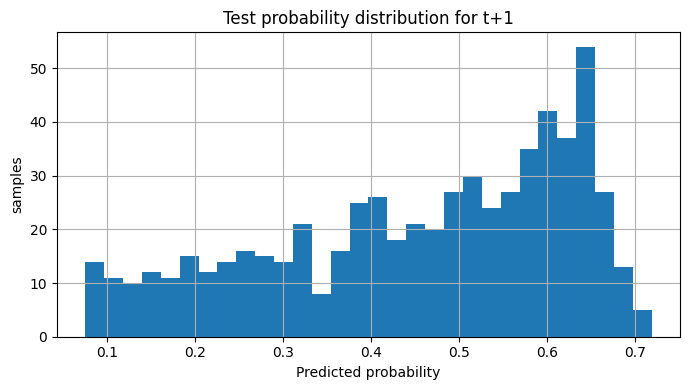

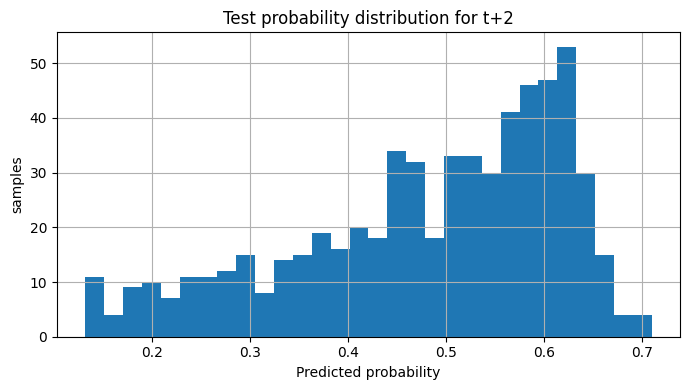

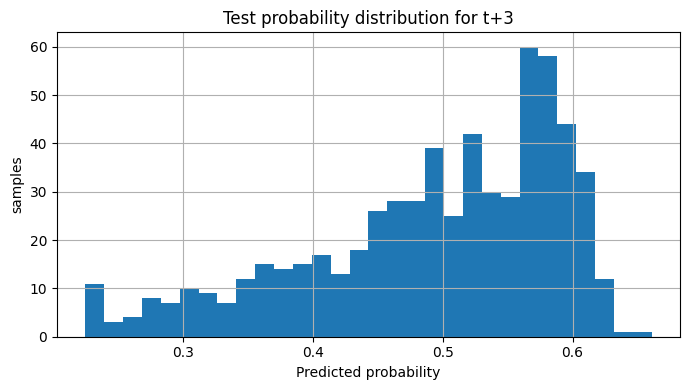

In [26]:

for h in range(1, HORIZON + 1):
    sub = test_pred[test_pred[f"mask_t+{h}"] == 1].copy()
    if len(sub) == 0:
        continue

    plt.figure(figsize=(7, 4))
    sub[f"prob_t+{h}"].hist(bins=30)
    plt.title(f"Test probability distribution for t+{h}")
    plt.xlabel("Predicted probability")
    plt.ylabel("samples")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"test_prob_dist_tplus{h}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 19. Example: threshold to 0/1

The model learns probabilities.  
If you want hard classifications, you can threshold them, for example at `0.5`.

You can later switch to a per-horizon threshold based on the validation set.

In [27]:


threshold_preview = test_pred.copy()
# Bruk per-horisont threshold fra val-settet
for h in range(1, HORIZON + 1):
    threshold_preview[f"pred_class_t+{h}"] = (
        threshold_preview[f"prob_t+{h}"] >= BEST_THRESHOLDS[h]
    ).astype(int)



threshold_preview.to_csv(OUTPUT_DIR / "test_predictions_thresholded.csv", index=False)
display(threshold_preview.head(10))

,patient_id,input_end_visit,target_t+1,mask_t+1,prob_t+1,target_t+2,mask_t+2,prob_t+2,target_t+3,mask_t+3,prob_t+3,pred_class_t+1,pred_class_t+2,pred_class_t+3
0,100842,4,0.0,1.0,0.462780,0.0,1.0,0.516114,0.0,1.0,0.509131,1,1,1
1,100842,5,0.0,1.0,0.448372,0.0,1.0,0.455937,0.0,1.0,0.469877,1,0,0
2,100898,4,0.0,1.0,0.549502,0.0,1.0,0.577183,0.0,1.0,0.575959,1,1,1
3,100898,5,0.0,1.0,0.550999,0.0,1.0,0.564153,1.0,1.0,0.536198,1,1,1
4,101124,4,0.0,1.0,0.321733,0.0,1.0,0.377020,0.0,1.0,0.438281,0,0,0
5,101124,5,0.0,1.0,0.464772,0.0,1.0,0.490233,0.0,1.0,0.524685,1,0,1
6,101680,4,0.0,1.0,0.404462,0.0,1.0,0.482796,0.0,1.0,0.498793,1,0,0
7,101799,4,0.0,1.0,0.472425,0.0,1.0,0.485149,0.0,1.0,0.521363,1,0,1
8,101799,5,0.0,1.0,0.487891,0.0,1.0,0.499270,0.0,1.0,0.564584,1,0,1
9,102420,4,0.0,1.0,0.502270,1.0,1.0,0.498870,0.0,1.0,0.479822,1,0,0


In [28]:
# Patients contributing at least one sample
train_pids = set(s["patient_id"] for s in train_samples)
val_pids   = set(s["patient_id"] for s in val_samples)
test_pids  = set(s["patient_id"] for s in test_samples)

print(f"Pasienter med samples — train: {len(train_pids)}, val: {len(val_pids)}, test: {len(test_pids)}")
print(f"Train-pasienter uten samples: {len(set(train_ids) - train_pids)}")
print(f"Val-pasienter uten samples:   {len(set(val_ids) - val_pids)}")
print(f"Test-pasienter uten samples:  {len(set(test_ids) - test_pids)}")

Pasienter med samples — train: 417, val: 94, test: 90
Train-pasienter uten samples: 336
Val-pasienter uten samples:   67
Test-pasienter uten samples:  72


## 20. Next steps

Natural next steps after this baseline runs:

1. expand the feature set gradually
2. tune `LOOKBACK` (e.g., 3, 4, 5) and `MIN_HISTORY_VISITS`
3. compare `HORIZON=1`, `HORIZON=3`, and `HORIZON=5`
4. tune the threshold per horizon on the validation set
5. try a simple hyperparameter search for `hidden_size`, `num_layers`, `dropout`
6. create patient-level summaries in addition to sample-level metrics

This notebook is meant to be a clean and safe starting point without leakage.